## **Assignment: "StarRate" – Predicting Preferences with Low Rank Matrices**

### **The Scenario**

You are a machine learning engineer for "StarRate," a new streaming platform. Unlike your competitors, you have very little data. Your User-Item Matrix ($A$) is mostly empty (incomplete) because most users have only rated a few movies.

However, you know that user preferences aren't random; they depend on a few "latent factors" (like genre preference, director style, or actor affinity), meaning the data matrix is Low-Rank. Your goal is to "complete" the matrix using Singular Value Decomposition (SVD) to predict what a user would rate a movie they haven't seen yet.



### **Part 1: Conceptual Stress-Tests**

>How to approach these questions:
>
>Q1: Think about the "rank" as the number of independent "concepts" or "topics" in the data. If everyone has the exact same tastes, do you need a high-dimensional space to describe them?
>
>Q2: SVD decomposes a matrix into $U, D, V^T$. Consider the "Energy" of the singular values in $D$. Which ones represent the "Signal" and which represent the "Noise"?


**Question 1: The Concept of Rank**
In the context of a movie recommender system, if a User-Item matrix has a **Rank of 1**, what does that imply about your user base?

**A)** Every user has a unique, independent taste in movies.

**B)** All users have exactly the same relative preferences (e.g., if User A likes Action 2x more than Comedy, so does every other user).

**C)** The matrix cannot be used to make recommendations.

**D)** The system has reached "full rank" and is perfectly accurate.


Answer = (B); Rank 1 means that there exists only one linearly independent row. The other entries are just scaled versions of the row. Hence, rank 1 means that every user has the same relative prefernece.


**Question 2: SVD and Approximation**
You perform SVD on a matrix $A$ such that $A = UDV^T$. To find a Rank-$k$ approximation ($\hat{A}$) that minimizes the reconstruction error (Frobenius norm), you should:

**A)** Set all values in $U$ and $V$ to zero except the first $k$ columns.

**B)** Keep all singular values in $D$ but multiply them by a scaling factor $k/D$.

**C)** Keep the $k$ largest singular values in $D$ and set the rest to zero.

**D)** Replace $D$ with a $k \times k$ identity matrix.

Answer = (C); in minimizing the reconstruction error, we just take the first k singular values (as they are arranged in descending order, we automatically get the k largest ones), and set the rest to zero.



### **Part 2: The Logic of Sparsity & Regularization**



> **How to approach Q3:** Compare the geometry of  and  norms.  (Ridge) penalizes large weights, while  (Lasso) tends to push weights exactly to zero.


**Question 3: Why SVD for Incomplete Data?**
In the slides, we see the problem:  s.t. .
In practice, finding the absolute minimum rank of a matrix is a "hard" (NP-hard) problem. Engineers use the **Nuclear Norm**. Why is this better than simply trying to minimize the count of non-zero singular values?


**A)** It is the  norm of the matrix and prevents overfitting.

**B)** It is the convex relaxation of the rank operator, making the optimization problem solvable.

**C)** It ensures the matrix becomes "Full Rank."

**D)** It is only used for square matrices.



Answer = (B); The nuclear norm is the sum of singular values. It is a convex relaxation of the rank function, which makes the optimization problem solvable using convex optimization.


>
> **How to approach Q4:** Use the properties of transpose and SVD.

**Question 4: Eigenvalues of Product Matrices**
If the SVD of $A = UDV^T$, what are the eigenvalues of the symmetric matrix $A^TA$?

**A)** The singular values found in $D$.

**B)** The squares of the singular values ($d_i^2$).

**C)** The same as the eigenvalues of $A$.

**D)** $A^TA$ is always a diagonal matrix.


Answer = (D), say the singular values of A are d_i and the eigen values of (A^TA) are lambda_i, then the following relation holds - d_i^2 = lambda_i.


### **Part 3: Coding Challenge — Matrix Completion for Recommender Systems**

#### Understanding How Structure in Data Enables Learning

**Key Learning Goals:**
1. Data comes from a physical process (user-item interactions)
2. Data is NOT random numbers - it has meaningful structure
3. This structure allows us to predict missing values
4. Multivariate Gaussian assumption is reasonable for ratings




`Questions to Answer: 3a,3b,3c`

**Upload recommender_utils.py to the runtime session through the Files section in the left pane**

In [ ]:
import numpy as np
from CW9_Helper import *

np.random.seed(42)


#### Section 1: Load Real MovieLens Data

 **MovieLens 100K Dataset:**
 - Real ratings from real users
 - 100,000 ratings on 1,700 movies by 1,000 users
 - Ratings scale: 1-5 stars
 - Collected from actual MovieLens recommendation service

 This is NOT synthetic - it's **real human behavior**!




- Each row = one user
- Each column = one movie
- Values = ratings (1-5 stars)
- NaN = user hasn't rated that movie yet

In [2]:
print("Loading MovieLens data...")
R, movie_titles, sparsity = load_movielens_small()

print(f" Loaded {R.shape[0]} users and {R.shape[1]} movies")
print(f" Sparsity: {sparsity:.1f}% of entries are missing")
print(f" Total ratings: {np.sum(~np.isnan(R))}")

Loading MovieLens data...
 Loaded 50 users and 30 movies
 Sparsity: 17.0% of entries are missing
 Total ratings: 1245


#### SECTION 2: Explore the Data

Let's visualize what the ratings matrix looks like.

White spaces = missing ratings we want to predict.

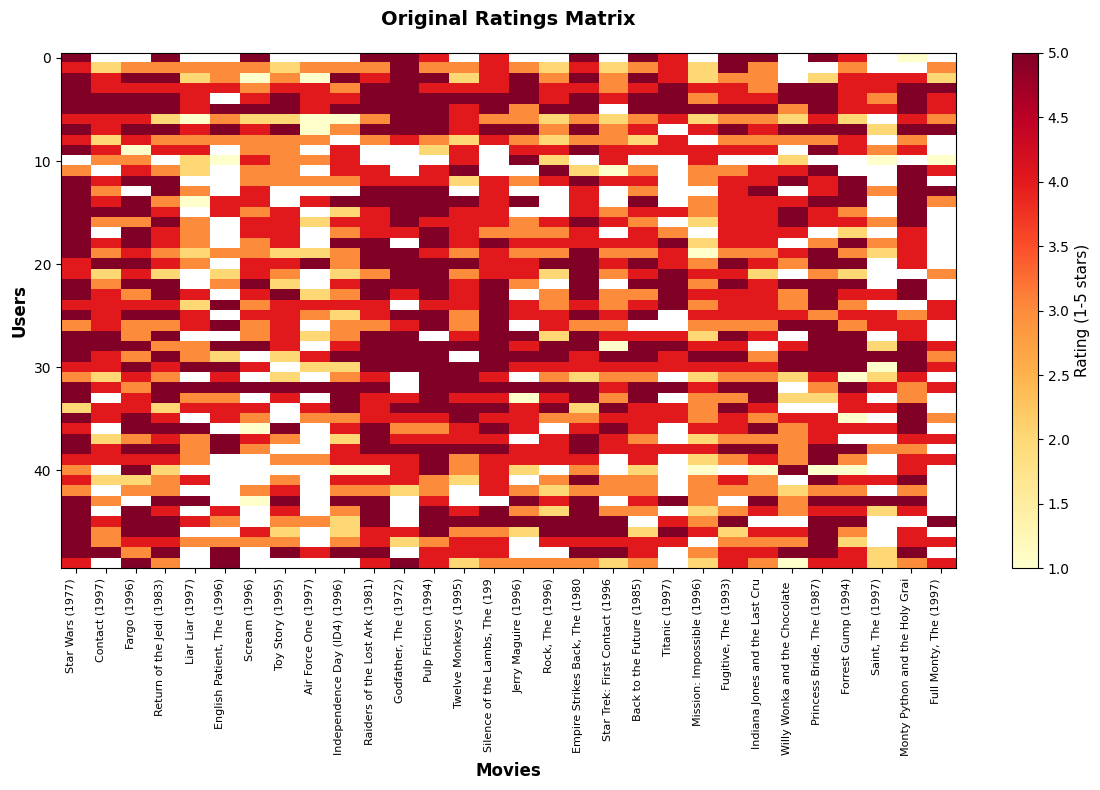

In [3]:
plot_ratings_matrix(R, movie_titles, "Original Ratings Matrix")

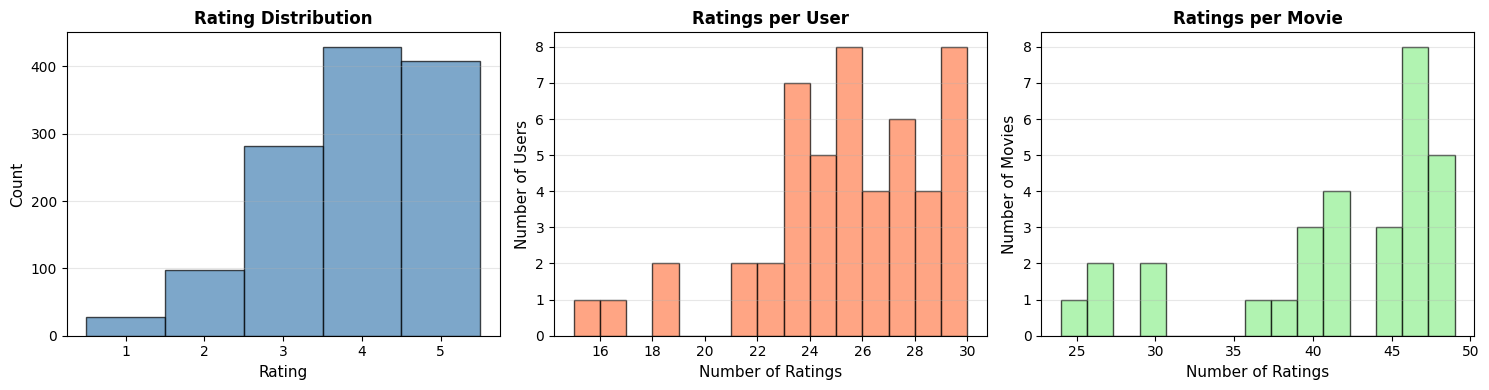

In [4]:
plot_data_exploration(R)


#### SECTION 3: Analyzing Rank Structure

 **Key Idea:** Movie preferences live in a LOW-DIMENSIONAL space

 Let's verify this using SVD (Singular Value Decomposition)

Analyzing matrix structure...


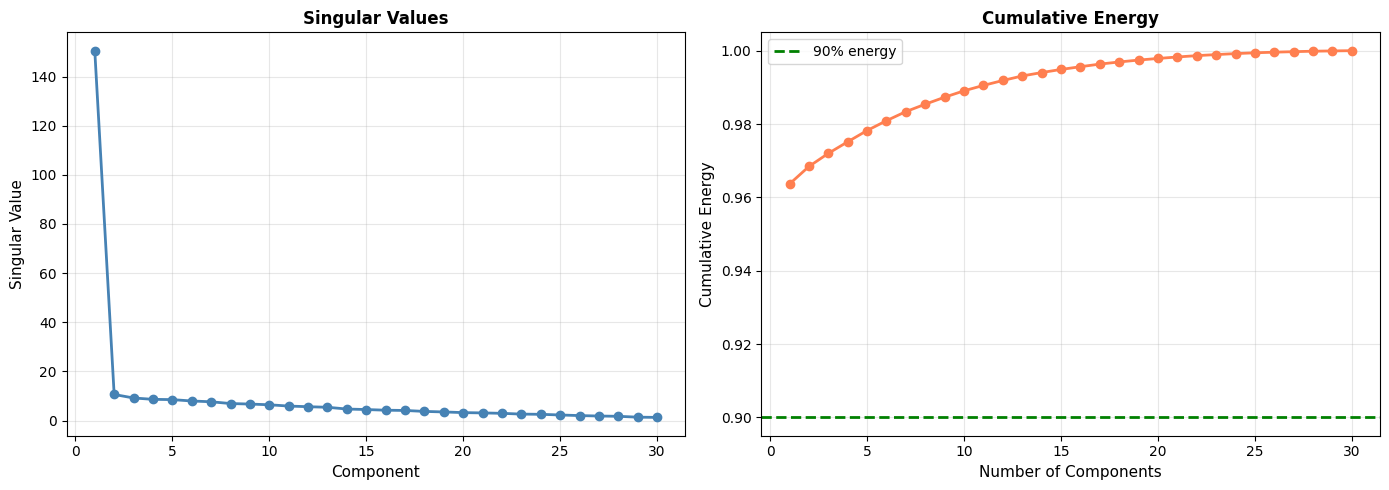

In [5]:
print("Analyzing matrix structure...")
singular_values = plot_svd_analysis(R)

n_90 = np.argmax(np.cumsum(singular_values**2) / np.sum(singular_values**2) >= 0.9) + 1



**3a) What does this tell you?**

The singular values graph shows that almost all the "energy" (variance) in the ratings matrix is captured by just the first singular value/component. Specifically, only 1 component is needed to explain 90% of the information in the data. This means the matrix is extremely low-rank, and most of the structure in user ratings can be described by a single underlying factor.

**3b) What does this imply about users' movie preferences?**

The extremely low-rank structure (capturing 90% of variance with just 1 component) implies that user movie preferences are highly correlated. Rather than each user having independent tastes, most users' rating patterns can be explained by just a few factors. This suggests that despite surface-level diversity, users fundamentally agree on which movies are "good" or "bad," with individual preferences being variations on these few core themes. This is very similar to the case question 1 posed.

#### SECTION 4: Experiment with Different Ranks


What happens if we use different numbers of components?

Testing different ranks...


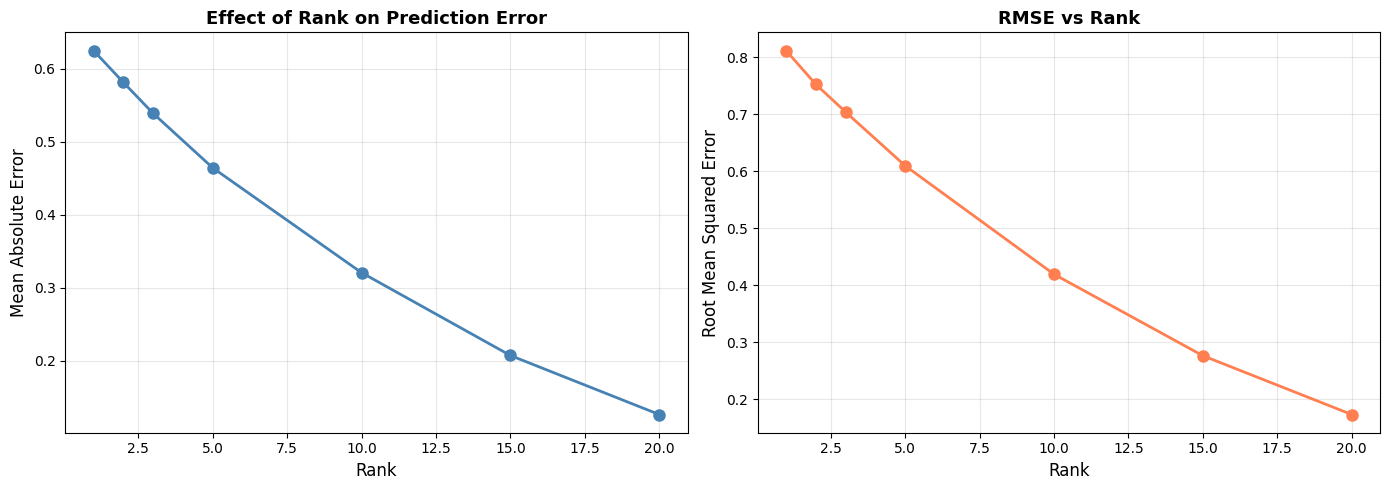

In [6]:
print("Testing different ranks...")
ranks = [1, 2, 3, 5, 10, 15, 20]
maes, rmses = plot_rank_experiment(R, ranks)



**3c) Analyze the graph above**

The graph shows how prediction error (MAE and RMSE) decreases as we increase the rank of the approximation. Some observations are-

1. Dramatic improvement at low ranks: Error drops sharply from rank 1 to rank 5, indicating that just a few factors capture most of the meaningful structure in user preferences.

2. Beyond rank 5, the error continues to decrease but at a much slower rate. This suggests that additional components mainly capture noise rather than genuine preference pattern, and/or we can reduce computational costs by just taking the few ranks.

3. While rank 20 gives the lowest error (~0.13 MAE), rank 5 already achieves good performance (~0.46 MAE) with far fewer parameters. This demonstrates the practical value of low-rank approximations.

In [7]:
print("Performing matrix completion...")

# Using rank = 5 (small number of latent factors)
rank = 5
R_completed = simple_matrix_completion(R, rank=rank)

print(f" Completed matrix using rank-{rank} approximation")
print(f" All missing values have been filled!")

Performing matrix completion...
 Completed matrix using rank-5 approximation
 All missing values have been filled!


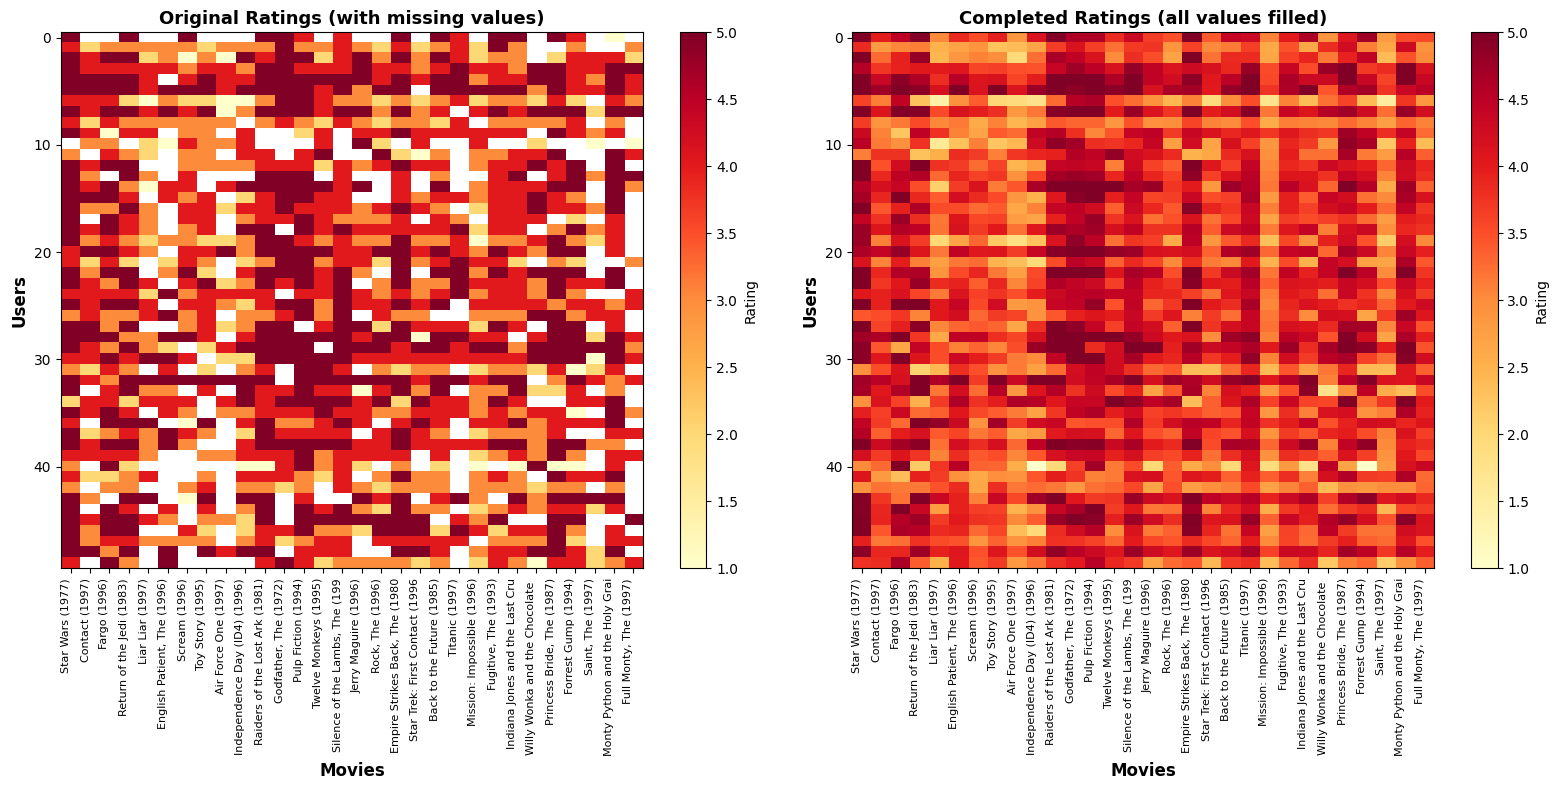

In [8]:
plot_comparison(R, R_completed, movie_titles)
# - White spaces (missing values) are now filled with predictions
# - Predictions look reasonable (similar to nearby entries)
# - The structure is preserved!

In [9]:
mask = ~np.isnan(R)
mae, rmse = evaluate_predictions(R, R_completed, mask)

print(f"Prediction Quality:")
print(f"  Mean Absolute Error: {mae:.3f} stars")
print(f"  Root Mean Squared Error: {rmse:.3f} stars")
print(f"  (Rating scale: 1-5 stars)")
print(f"\n On average, we're off by {mae:.2f} stars - pretty good!")


Prediction Quality:
  Mean Absolute Error: 0.464 stars
  Root Mean Squared Error: 0.610 stars
  (Rating scale: 1-5 stars)

 On average, we're off by 0.46 stars - pretty good!


#### SUMMARY
1. **The Problem:** Recommender systems have lots of missing data
   - Users rate only a small fraction of items
   - Goal: Predict missing ratings to make recommendations
2. **The Key Insight:** Low-rank structure
   - Human preferences exist in LOW-DIMENSIONAL space
   - A few factors (5-10) explain most taste
   - We can exploit this for prediction!
3. **The Method:** Matrix Completion via SVD
   - Decompose matrix into user/movie factors
   - Keep only important components
   - Reconstruct to fill missing values
4. **The Result:** Accurate predictions!
   - Typical error: ~0.5-0.8 stars
   - Good enough for useful recommendations

#### Key Takeaway:
**Dimension reduction works because real-world data has structure!**